# Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime

In [2]:
df = pd.read_excel("data/Online Retail.xlsx")

In [3]:
df.head() 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Data Cleaning

In [4]:
df.shape 

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum() # 2 columns has null values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.describe() # 3 columns are numerical 

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
df = df.dropna(subset=["CustomerID"])

In [10]:
df.shape

(406829, 8)

In [11]:
df.duplicated().sum()

5225

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

0

In [14]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [15]:
df[~df["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [17]:
df[df["Quantity"] < 0].head() #negative-cancel/returns,zero-invalid transaction

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [18]:
df = df[df["Quantity"] > 0] #positive

In [19]:
df[df["Quantity"] < 0].shape #check

(0, 8)

In [20]:
df[df["UnitPrice"] <= 0].head() #negative-error,zero-not useful for revenue

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom


In [21]:
df = df[df["UnitPrice"] > 0] #positive

In [22]:
df[df["UnitPrice"] <= 0].shape #check

(0, 8)

In [23]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [24]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [25]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int32         
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 28.5+ MB


In [27]:
df.describe()

,Quantity,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,15287.843865,22.631500
std,180.492832,22.241836,1713.539549,311.099224
min,1.000000,0.001000,12346.000000,0.001000
25%,2.000000,1.250000,13955.000000,4.950000
50%,6.000000,1.950000,15150.000000,12.450000
75%,12.000000,3.750000,16791.000000,19.800000
max,80995.000000,8142.750000,18287.000000,168469.600000


In [28]:
df.to_csv("data/cleaned_ecommerce_data.csv", index=False)

# EDA

In [29]:
df = pd.read_csv("data/cleaned_ecommerce_data.csv")

In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [31]:
df.shape

(392692, 9)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  int64  
 7   Country      392692 non-null  object 
 8   TotalPrice   392692 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 27.0+ MB


## Top 10 countries by revenue

In [33]:
total_revenue = df["TotalPrice"].sum()

In [34]:
print("Total Revenue:", total_revenue)

Total Revenue: 8887208.894


In [35]:
country_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

In [36]:
country_revenue 

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

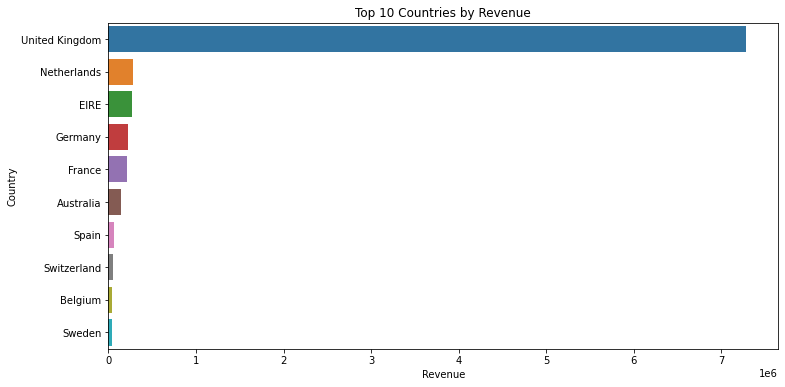

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(x=country_revenue.values, y=country_revenue.index)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

## Top 10 selling products

In [38]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

In [39]:
top_products 

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

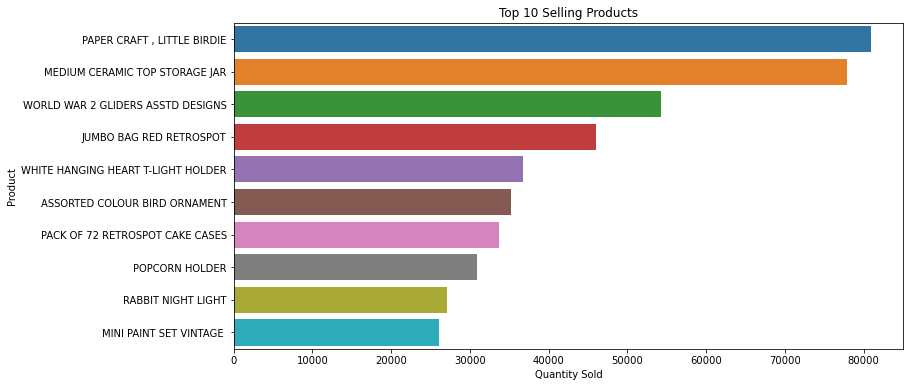

In [40]:
plt.figure(figsize=(12,6))

sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

## Monthly revenue

In [41]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]) #convert date column

In [42]:
df["Month"] = df["InvoiceDate"].dt.to_period("M") #convert month column

In [43]:
monthly_sales = df.groupby("Month")["TotalPrice"].sum() #monthly revenue

In [44]:
monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64

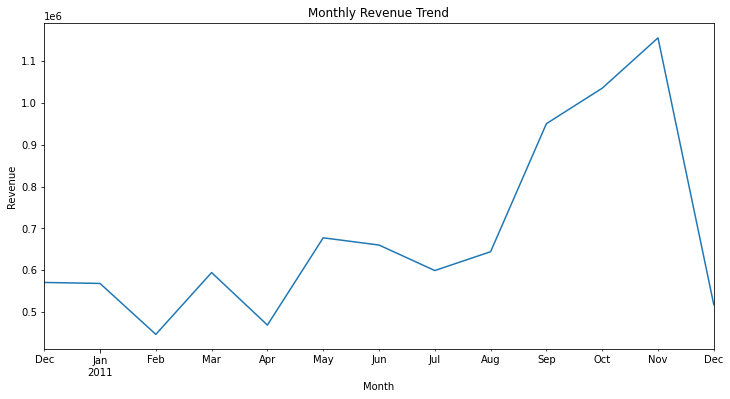

In [45]:
monthly_sales.plot(figsize=(12,6))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Top 10 customers by revenue

In [46]:
top_customers = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

In [47]:
top_customers #top customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64

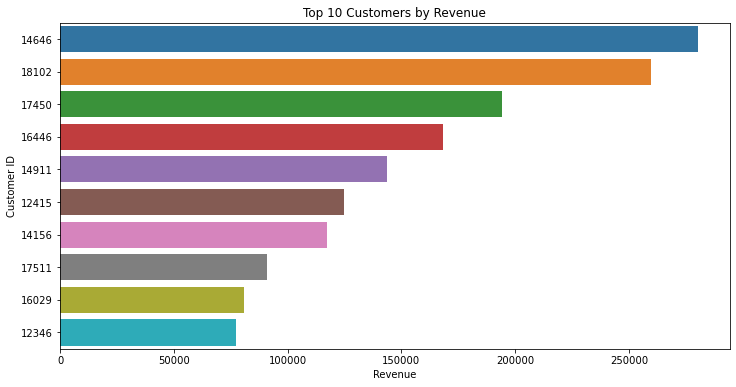

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(x=top_customers.values,y=top_customers.index.astype(str))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.show()

# RFM Segmentation

In [49]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]) #convert invoicedate to datetime

In [50]:
reference_date = df["InvoiceDate"].max()

In [51]:
reference_date #find latest date in dataset

Timestamp('2011-12-09 12:50:00')

### Create RFM Table

In [52]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days, #recency
    "InvoiceNo": "nunique", #frequency
    "TotalPrice": "sum"  #monetary
})

In [53]:
rfm.columns = ["Recency", "Frequency", "Monetary"] #rename columns

In [54]:
rfm.head() #rfm table  (r-1,f-7,m-4310 - this is loyal customer)

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [55]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


### Create RFM score

In [56]:
# recency-low recency is better (very recent purchase)
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [57]:
#frequency-high frequency is better (ordering many times)
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [58]:
#monetary-high monetary is better (high spending) 
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

### Create Combined RFM Score

In [59]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

In [60]:
rfm.head() #table (555-best customer)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,325,1,77183.60,1,1,5,115
12347,1,7,4310.00,5,5,5,555
12348,74,4,1797.24,2,4,4,244
12349,18,1,1757.55,4,1,4,414
12350,309,1,334.40,1,1,2,112


In [61]:
#convert scores(categorical labels) to string
rfm["R_Score"] = rfm["R_Score"].astype(str)
rfm["F_Score"] = rfm["F_Score"].astype(str)
rfm["M_Score"] = rfm["M_Score"].astype(str)

## Customer segment distribution

In [62]:
#create customer segments
def segment_customer(row):

    if row["R_Score"] == "5" and row["F_Score"] == "5":
        return "Champions"

    elif row["F_Score"] in ["4", "5"]:
        return "Loyal Customers"

    elif row["R_Score"] == "5":
        return "Recent Customers"

    elif row["R_Score"] in ["1", "2"]:
        return "At Risk"

    else:
        return "Regular Customers"
    
#High Recency + High Frequency-Champions
#High Frequency-Loyal
#Very Recent-Recent Customers
#Low Recency-At Risk
#Others-Regular

In [63]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1) #apply segmentation

In [64]:
rfm["Segment"].value_counts() #check segment distribution

At Risk              1433
Loyal Customers      1296
Regular Customers     935
Champions             439
Recent Customers      235
Name: Segment, dtype: int64

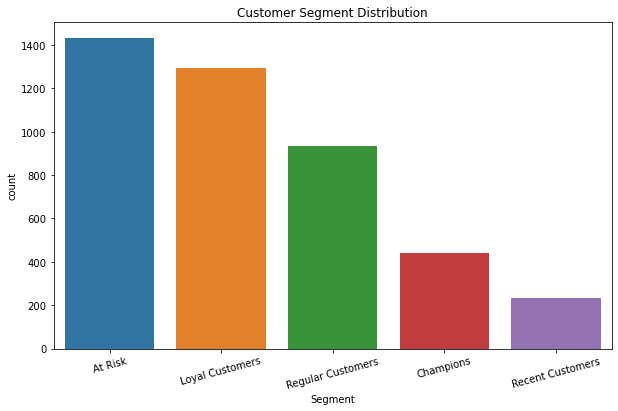

In [65]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xticks(rotation=15)
plt.show()

## Revenue by customer segment

In [66]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

In [67]:
segment_revenue

Segment
Champions            4033018.420
Loyal Customers      3085913.151
At Risk               884735.393
Regular Customers     561654.160
Recent Customers      321887.770
Name: Monetary, dtype: float64

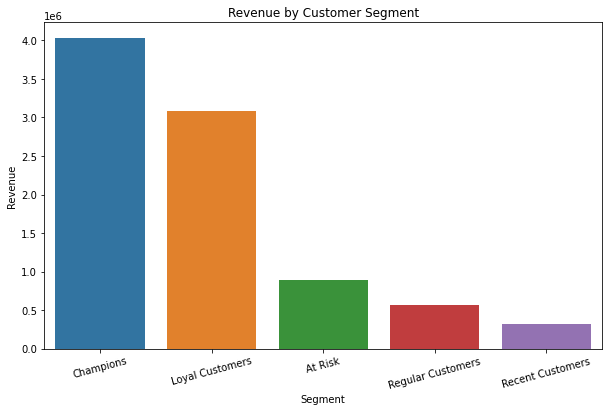

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(x=segment_revenue.index, y=segment_revenue.values)
plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=15)
plt.show()

## Recency distribution

In [69]:
top_customers = rfm.sort_values(
    by="Monetary",
    ascending=False
).head(10)

top_customers  # top 10 customers

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
14646,1,73,280206.02,5,5,5,555,Champions
18102,0,60,259657.30,5,5,5,555,Champions
17450,7,46,194390.79,5,5,5,555,Champions
16446,0,2,168472.50,5,3,5,535,Recent Customers
14911,0,201,143711.17,5,5,5,555,Champions
12415,23,21,124914.53,4,5,5,455,Loyal Customers
14156,9,55,117210.08,5,5,5,555,Champions
17511,2,31,91062.38,5,5,5,555,Champions
16029,38,63,80850.84,3,5,5,355,Loyal Customers


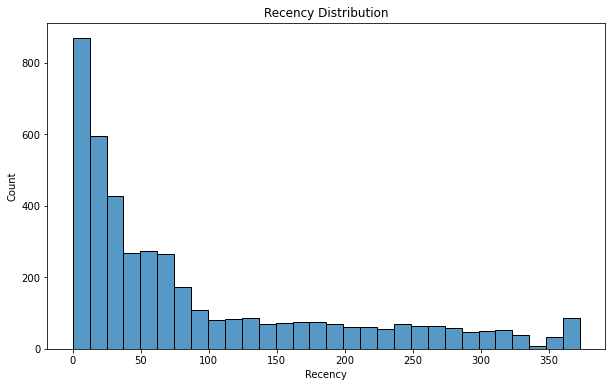

In [70]:
plt.figure(figsize=(10,6))

sns.histplot(rfm["Recency"], bins=30)
plt.title("Recency Distribution")
plt.show() #recency distribution